<a href="https://colab.research.google.com/github/miguelangelortizpenaranda/ortizpastorserna/blob/main/bandit_experiment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Grupo 1: Bandido de K-Brazos (Distribución de Bernoulli)

Autor:

- Miguel Ángel Ortiz Peñaranda

## Introducción

El bandido de k-brazos, o k-armed bandit, supone un problema clásico de aprendizaje por refuerzo. En él, disponemos de un número K de elementos que, al activarlos, nos otorgan una recompensa determinada, desconocida a priori. Es esta recompensa la que nos interesa maximizar a lo largo del tiempo, por medio de un método que, bien explore distintos "brazos" o soluciones, bien explote la solución que en un momento dado parezca la mejor, o bien mediante un compendio de ambas prácticas.




## Preparación del entorno

Para el funcionamiento de este notebook por parte de Colab, es necesario ejecutar las líneas de código que se encuentran a continuación,
las cuales se encargan de clonar el repositorio para que el código esté disponible por parte de este notebook.


In [16]:
#!rm -r ortizpastorserna/
#!git clone https://github.com/miguelangelortizpenaranda/ortizpastorserna.git
#!cd ortizpastorserna/

A continuación añadimos al path los directorios de código fuente, tanto para ejecución en Colab como para ejecución en un IDE local.

In [17]:
#@title Importamos todas las clases y funciones
import sys


# Añadir los directorios fuentes al path de Python
sys.path.append('/content/ortizpastorserna/src/eml_k_bandit')
sys.path.append('src/eml_k_bandit')

# Verificar que se han añadido correctamente
print(sys.path)

#!ls


['/home/miguel/.local/share/JetBrains/pycharm-2025.2.4/plugins/python-ce/helpers/jupyter_debug', '/home/miguel/.local/share/JetBrains/pycharm-2025.2.4/plugins/python-ce/helpers/pydev', '/home/miguel/PycharmProjects/exml-ortizpenaranda', '/usr/lib/python314.zip', '/usr/lib/python3.14', '/usr/lib/python3.14/lib-dynload', '', '/home/miguel/PycharmProjects/exml-ortizpenaranda/.venv/lib/python3.14/site-packages', '/content/ortizpastorserna/src/eml_k_bandit', 'src/eml_k_bandit', '/content/ortizpastorserna/src/eml_k_bandit', 'src/eml_k_bandit']


Realizamos los imports correspondientes a los tipos implementados de variantes del bandido de k-brazos, así como los algoritmos que se han modelado, y algunas otras librerías adicionales para representación de los resultados.

In [18]:

import numpy as np
from typing import List

from algorithms import Algorithm, EpsilonGreedy, UCB1, Softmax
from arms import ArmBinomial, Bandit
from plotting import get_algorithm_label, plot_average_rewards, plot_optimal_selections, plot_regret
from util import get_results_average, convert_results

## Metodología de trabajo

Se propone una metodología de trabajo en la que se va a probar, tanto con distintas variantes del bandido de K-brazos (Testearemos parámetros como número de brazos o desviación), como con distintas variantes de los algoritmos que determinan en qué medida el bandido lleva a cabo una función de exploración o de explotación de los brazos, de cara a conseguir la mayor recompensa a lo largo del tiempo. Siendo así, seguiremos los siguientes pasos:

1. En cada experimento que se haga con el bandido, compararemos los algoritmos implementados (Epsilon-Greddy, UCB, Softmax), variando sus parámetros principales. Estos parámetros serán siempre iguales entre distintas ejecuciones, para asegurar la consistencia en el comportamiento de los mismos.
2. Se realizarán variaciones entre: Número de pasos (steps), número de brazos (k), y valor de la desviación en la distribución normal del bandido.
3. Para cada ejecución, se comparará el comportamiento de cada variante del algoritmo atendiendo a las métricas de: Porcentaje de elecciones óptimas en el 20% último de pasos (donde el algoritmo debe acercarse mayormente a la convergencia), y rechazo acumulado para ese algoritmo al final de la ejecución. La cantidad de pasos finales a tener en cuenta para el porcentaje de elecciones óptimas la hemos considerado así para quitarnos el tramo iniciar de los algoritmos donde el comportamiento sea mayoritariamente exploratorio.
4. Para cada experimento, se dará una valoración de los resultados obtenidos.
5. Se pomediarán los resultados obtenidos para cada variante, de cara a establecer una idea general de qué algoritmos funcionan mejor.
6. Finalmente, se darán unas conclusiones finales que indiquen qué algoritmo o algoritmos se considera que presentan un mejor comportamiento.


Fijamos la semilla aleatoria para asegurar la reproducibilidad de los resultados de las ejecuciones en distintos dispositivos.

In [19]:
seed = 1234
np.random.seed(seed)  # Fijar la semilla para reproducibilidad

runs = 200 # El número de ejecuciones que utilizamos para promediar resultados va a ser siempre constante en nuestros experimentos

## Experimento

Este código se encarga de ejecutar un número de `runs` concretos para el problema de k-armed bandit. Utilizando una lista de algoritmos y ejecutando cada algoritmo una serie de pasos, para acabar obteniendo un promedio de recompensas por ejecución, así como el porcentaje de selecciones del brazo óptimo para dichas ejecuciones.


In [20]:

def run_experiment(bandit: Bandit, algorithms: List[Algorithm], steps: int, runs: int):

    """
    Ejecuta el problema del bandido de k-brazos un número de runs concretos, una serie de pasos para cada algoritmo especificado.
    :param bandit: Implementación del bandido de k-brazos a ejecutar
    :param algorithms: Listado de algoritmos a ejecutar para esa implementación del bandido
    :param steps: Número de pasos a ejecutar para cada algoritmo individual
    :param runs: Número de ejecuciones independientes que se va a hacer para todos y cada uno de los algoritmos
    :return: Promedio de recompensas, arrepentimiento acumulado, y porcentaje de soluciones óptimas
    """
    optimal_arm = bandit.optimal_arm  # Se elige el brazo óptimo en base a la implementación del bandido. Necesario para calcular el porcentaje de selecciones óptimas.
    rewards = np.zeros((len(algorithms), steps)) # Matriz para almacenar las recompensas promedio.
    regrets = np.zeros((len(algorithms), steps)) # Matriz para almacenar el regret
    optimal_selections = np.zeros((len(algorithms), steps))  # Matriz para almacenar el porcentaje de selecciones óptimas.

    np.random.seed(seed)  # Asegurar reproducibilidad de resultados.

    for run in range(runs):
        current_bandit = Bandit(arms=bandit.arms) # Crea una instancia nueva del bandido con la distribución que especifica la implementación pasada como parámetro (normal, binomial)

        for algo in algorithms:
            algo.reset() # Reiniciar los valores de los algoritmos.

        total_rewards_per_algo = np.zeros(len(algorithms)) # Acumulador de recompensas por algoritmo. Necesario para calcular el promedio.

        for step in range(steps):
            for idx, algo in enumerate(algorithms):
                chosen_arm = algo.select_arm() # Seleccionar un brazo según la política del algoritmo.
                reward = current_bandit.pull_arm(chosen_arm) # Obtener la recompensa del brazo seleccionado.
                algo.update(chosen_arm, reward) # Actualizar el valor estimado del brazo seleccionado.

                optimal_reward = bandit.arms[optimal_arm].get_expected_value() # Recompensa óptima, para calcular regret

                rewards[idx, step] += reward # Acumular la recompensa obtenida en la matriz rewards para el algoritmo idx en el paso step.
                regrets[idx, step] += (optimal_reward - reward) # Acumulamos arrepentimiento como diferencia entre recompensa óptima y la obtenida
                total_rewards_per_algo[idx] += reward # Acumular la recompensa obtenida en total_rewards_per_algo para el algoritmo idx.

                 # Modificamos optimal_selections cuando el brazo elegido se corresponda con el brazo óptimo optimal_arm
                if chosen_arm == optimal_arm:
                  optimal_selections[idx, step] += 1

    # Promediamos recompensas entre ejecuciones
    rewards /= runs

    # Promediamos arrepentimientos entre ejecuciones
    regrets /= runs
    # Calculamos arrepentimiento acumulado a lo largo del array
    cumulative_regret = np.cumsum(regrets, axis=1)

    # Calculamos el porcentaje de selecciones óptimas y almacenar en optimal_selections
    optimal_selections /= runs
    optimal_selections *= 100

    total_steps = optimal_selections.shape[1]
    final_performance = optimal_selections[:, int(total_steps * 0.8):]
    avg_optimal_rates = np.mean(final_performance, axis=1)

    total_regret = cumulative_regret[:, -1] # Coge el ultimo valor

    # Mostrar resultados
    for i, rate in enumerate(avg_optimal_rates):
        print(f"Algoritmo {get_algorithm_label(algorithms[i])}: {rate:.2f}% de elecciones óptimas en el 20% último de steps")
        print(f"Algoritmo {get_algorithm_label(algorithms[i])}: {total_regret[i]:.2f} de arrepentimiento acumulado\n")

    return rewards, cumulative_regret, optimal_selections, avg_optimal_rates, total_regret


## Ejecución del experimento

A continuación, utilizando la función definida anteriormente, vamos a ejecutar el experimento del bandido. Esto se va a realizar para la variante del bandido con distribución de Bernoulli, con una probabilidad entre 0.1 y 0.9 por brazo, y recompensa máxima = 1 por brazo, que es lo que caracteriza a este tipo de distribución. Los "pulls" se van a dividir por tanto únicamente en acierto o rechazo.

Adicionalmente, se va a probar con una serie de algoritmos:
- Epsilon Greedy, con valores de epsilon=[0, 0.01, 0.1], que determinan un comportamiento exploratorio cada vez mayor.
- UCB-1, con c=0.5, c=1, c=2, que determina también el peso de la componente exploratoria en el algoritmo.
- Softmax, con una temperatura de 0.5

Estos algoritmos se van a probar para cada variante del experimento, y mostraremos el promedio de recompensa y el porcentaje de decisiones acertadas para el mejor brazo en cada caso.

Vamos a crear, asimismo, una función que nos permitirá ejecutar el experimento para distinto número de brazos, y distinto número de ejecuciones, para ver si el comportamiento de los algoritmos cambia al modificar estos parámetros

In [21]:

def execute_bandit_experiment(k: int, steps: int, runs: int, bandit: Bandit):
    """
    Ejecuta el experimento para un bandido pasado como parámetro, teniendo en cuenta el número de brazos, cuántas ejecuciones
    queremos promediar, y el número de pasos para los que se va a probar el algoritmo.
    :param k: número de brazos del bandido
    :param steps: número de pasos en los que se va a ejecutar el algoritmo
    :param runs: número de ejecuciones para realizar un promedio de los resultados
    :param bandit: bandido para el que vamos a realizar el experimento
    """
    # Definir los algoritmos a comparar. En este caso son 3 algoritmos epsilon-greedy con diferentes valores de epsilon.
    algorithms = [EpsilonGreedy(k=k, epsilon=0), EpsilonGreedy(k=k, epsilon=0.01), EpsilonGreedy(k=k, epsilon=0.1), UCB1(k=k, c=0.5), UCB1(k=k, c=1), UCB1(k=k, c=2), Softmax(k=k, temperature=0.5), Softmax(k=k, temperature=1), Softmax(k=k, temperature=2)]

    print(bandit)
    optimal_arm = bandit.optimal_arm
    print(f"Optimal arm for bandit is: {optimal_arm + 1} with expected reward={bandit.get_expected_value(optimal_arm)}\n")
    rewards, regrets, optimal_selections, avg_optimal_rates, total_regret = run_experiment(bandit, algorithms, steps, runs)  # Ejecutar el experimento y obtener las recompensas promedio y promedio de las selecciones óptimas
    results = convert_results(algorithms=algorithms, avg_optimal_rates=avg_optimal_rates, total_regret=total_regret)
    # Graficar los resultados
    plot_optimal_selections(steps, optimal_selections, algorithms)
    plot_average_rewards(steps, rewards, algorithms)
    plot_regret(steps, regrets, algorithms)

    return results


## Ejecución del experimento para Variante 1 del bandido

En primer lugar, vamos a realizar el experimento para una variante del bandido de 10 brazos, con distribución de bernoulli (solo nos devuelve 0 o 1, acierto o error). En este caso, solo existe una tirada para un brazo determinado, que nos dará acierto con una probabilidad $p$ desconocida a priori, y error con una probabilidad de $1-p$. Esta probabilidad, al igual que en la distribución binomial, es desconocida y se calcula de forma aleatoria al generar los brazos.


In [22]:
# Definimos el bandido (se comparte entre experimentos)
bandit = Bandit(arms=ArmBinomial.generate_arms(k=10, n=1)) # Generar un bandido con k brazos de distribución binomial. El valor de máxima recompensa será 10


### Ejecución de los algoritmos para 1000 steps

Nos disponemos a ejecutar el experimento para 1000 pasos inicialmente.

Bandit with 10 arms: ArmBinomial(n=1, p=0.25), ArmBinomial(n=1, p=0.6), ArmBinomial(n=1, p=0.45), ArmBinomial(n=1, p=0.72), ArmBinomial(n=1, p=0.73), ArmBinomial(n=1, p=0.32), ArmBinomial(n=1, p=0.74), ArmBinomial(n=1, p=0.87), ArmBinomial(n=1, p=0.8), ArmBinomial(n=1, p=0.39)
Optimal arm for bandit is: 8 with expected reward=0.87

Algoritmo EpsilonGreedy (epsilon=0): 60.50% de elecciones óptimas en el 20% último de steps
Algoritmo EpsilonGreedy (epsilon=0): 47.20 de arrepentimiento acumulado

Algoritmo EpsilonGreedy (epsilon=0.01): 45.06% de elecciones óptimas en el 20% último de steps
Algoritmo EpsilonGreedy (epsilon=0.01): 190.17 de arrepentimiento acumulado

Algoritmo EpsilonGreedy (epsilon=0.1): 72.37% de elecciones óptimas en el 20% último de steps
Algoritmo EpsilonGreedy (epsilon=0.1): 73.63 de arrepentimiento acumulado

Algoritmo UCB1 (c=0.5): 72.68% de elecciones óptimas en el 20% último de steps
Algoritmo UCB1 (c=0.5): 69.54 de arrepentimiento acumulado

Algoritmo UCB1 (c=1):

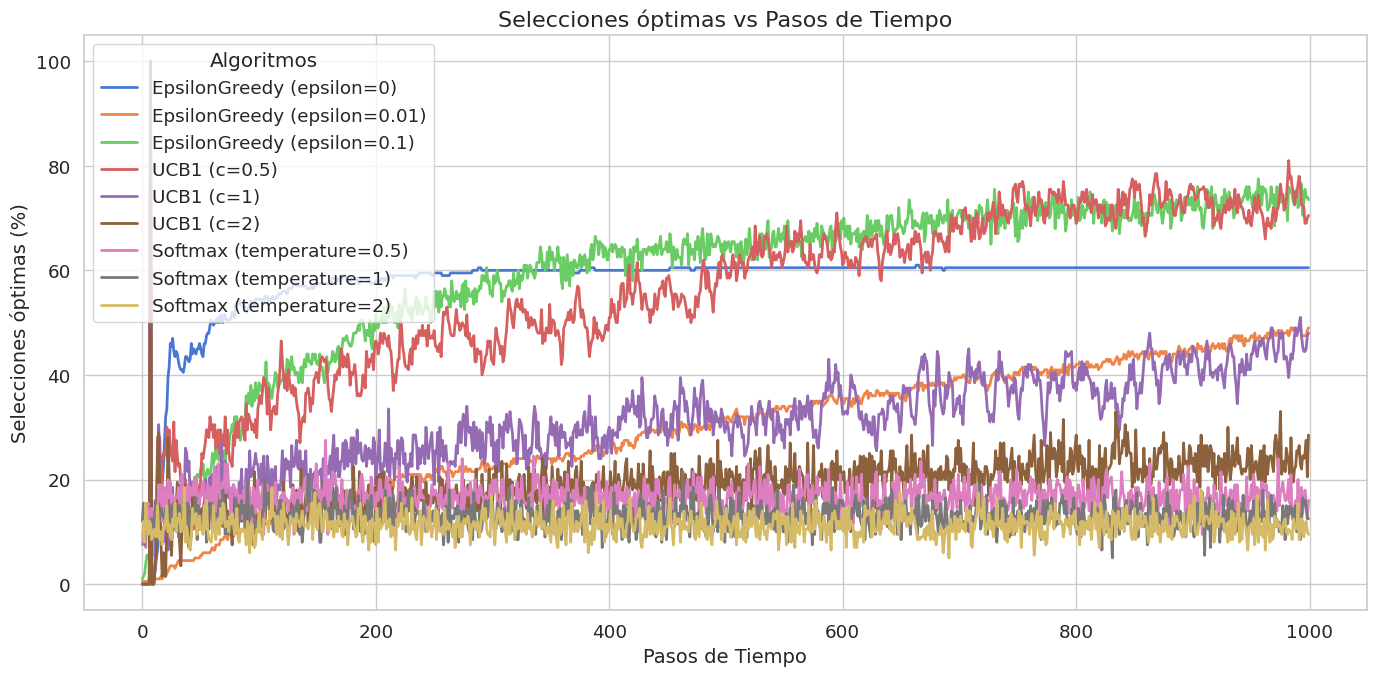

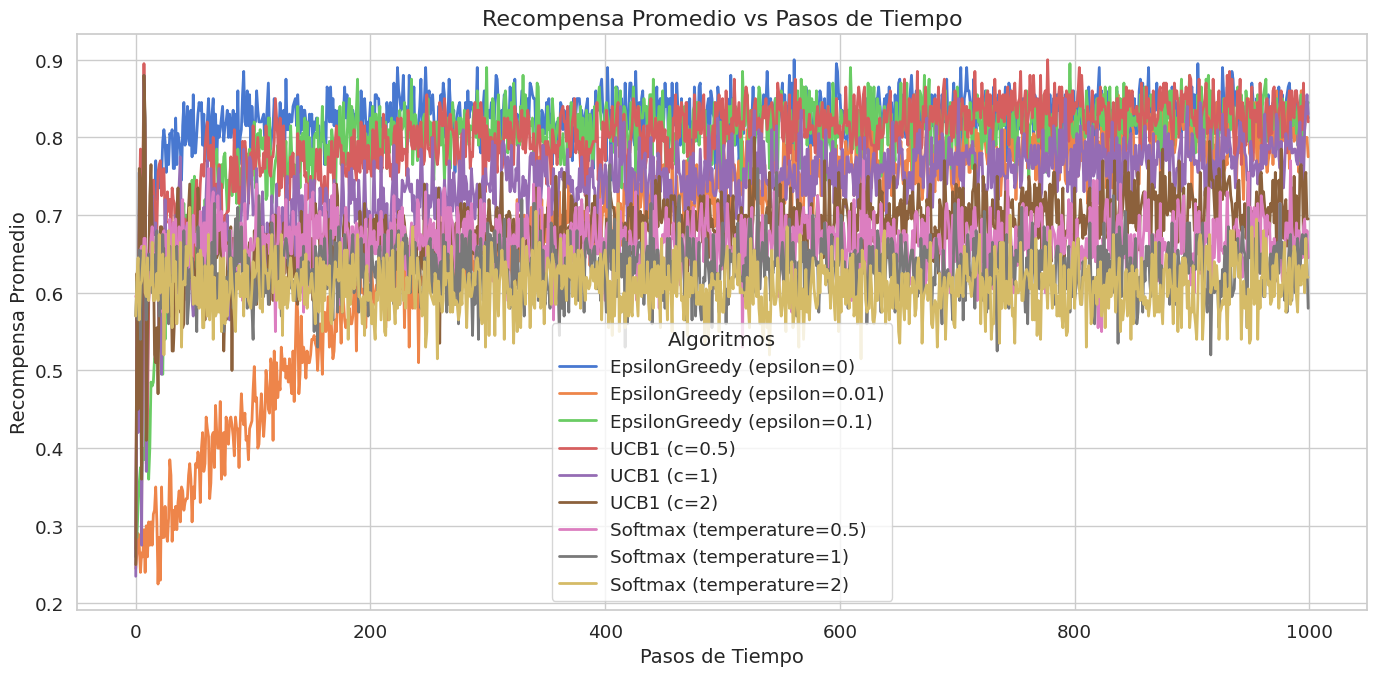

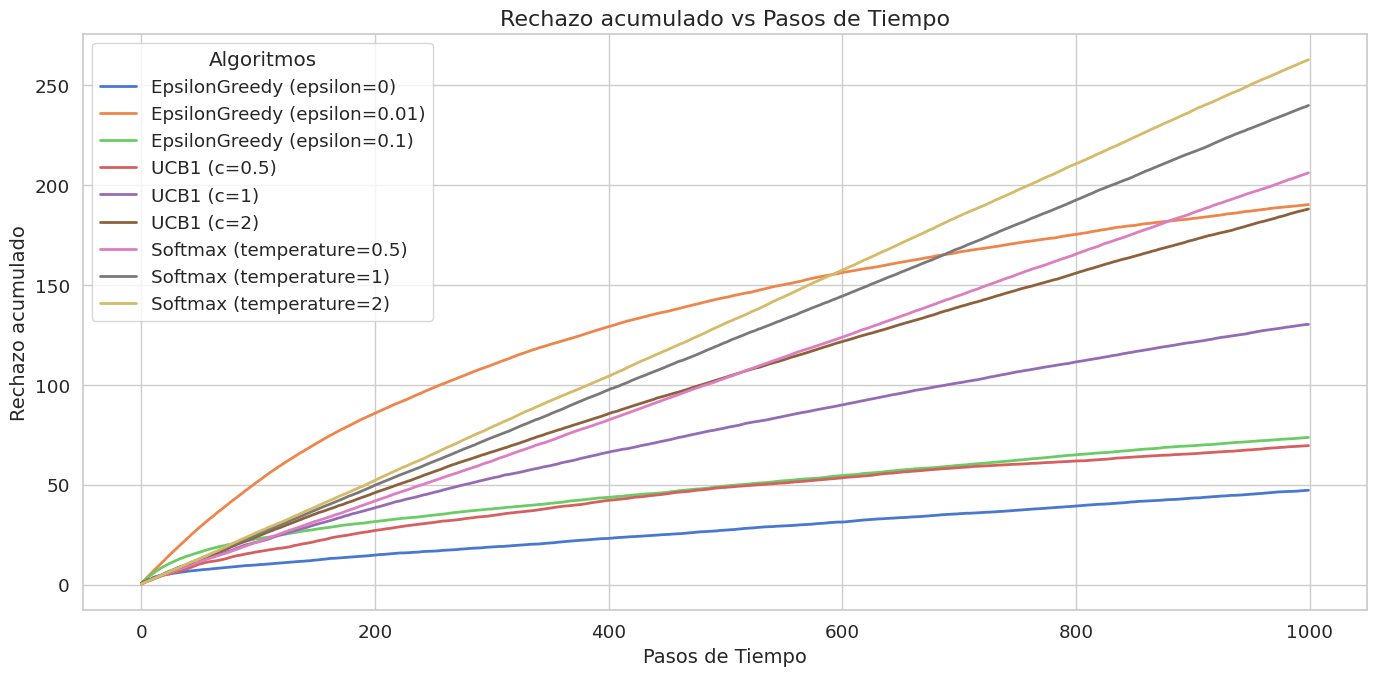

In [23]:
results_ex1_1 = execute_bandit_experiment(k=10, steps=1000, runs=runs, bandit = bandit)

### Valoración de los resultados

Vemos como, en 1000 pasos, en general a todos los algoritmos les cuesta encontrar el brazo óptimo. En este caso, el algoritmo que mejor resultado ha obtenido en cuanto a porcentaje de aciertos ha sido Epsilon-Greedy con epsilon=0.1, seguido muy de cerca por UCB-1 con c=0.5. Vemos como ambos se acercan al 80% de aciertos hacia el final del experimento.

Podemos observar también como el algoritmo Epsilon-Greedy con epsilon=0 parece haber encontrado un brazo subóptimo al principio del experimento, y ya se estanca en el mismo.

Las variantes de Softmax vuelven a demostrar un comportamiento poco deseable, situándose apenas en el 20% de aciertos al final de la ejecución de esta variante del bandido.

Por último, si nos fijamos en la gráfica de rechazo acumulado, coincide con lo que hemos mencionado, siendo Softmax quien mayor rechazo acumula a lo largo del tiempo, y los que menor rechazo UCB-1 y Epsilon-Greedy con componente exploratoria. Normalmente, en los algoritmos que van explorando para acabar encontrando el brazo óptimo, el rechazo acumulado se va estabilizando y llegan a un punto que no aumenta prácticamente.


### Ejecución de los algoritmos para 2000 steps

A continuación, vamos a repetir el experimento para 2000 pasos, manteniendo el número de runs.

Bandit with 10 arms: ArmBinomial(n=1, p=0.25), ArmBinomial(n=1, p=0.6), ArmBinomial(n=1, p=0.45), ArmBinomial(n=1, p=0.72), ArmBinomial(n=1, p=0.73), ArmBinomial(n=1, p=0.32), ArmBinomial(n=1, p=0.74), ArmBinomial(n=1, p=0.87), ArmBinomial(n=1, p=0.8), ArmBinomial(n=1, p=0.39)
Optimal arm for bandit is: 8 with expected reward=0.87

Algoritmo EpsilonGreedy (epsilon=0): 59.50% de elecciones óptimas en el 20% último de steps
Algoritmo EpsilonGreedy (epsilon=0): 90.04 de arrepentimiento acumulado

Algoritmo EpsilonGreedy (epsilon=0.01): 60.50% de elecciones óptimas en el 20% último de steps
Algoritmo EpsilonGreedy (epsilon=0.01): 239.76 de arrepentimiento acumulado

Algoritmo EpsilonGreedy (epsilon=0.1): 77.83% de elecciones óptimas en el 20% último de steps
Algoritmo EpsilonGreedy (epsilon=0.1): 113.38 de arrepentimiento acumulado

Algoritmo UCB1 (c=0.5): 83.32% de elecciones óptimas en el 20% último de steps
Algoritmo UCB1 (c=0.5): 95.18 de arrepentimiento acumulado

Algoritmo UCB1 (c=1)

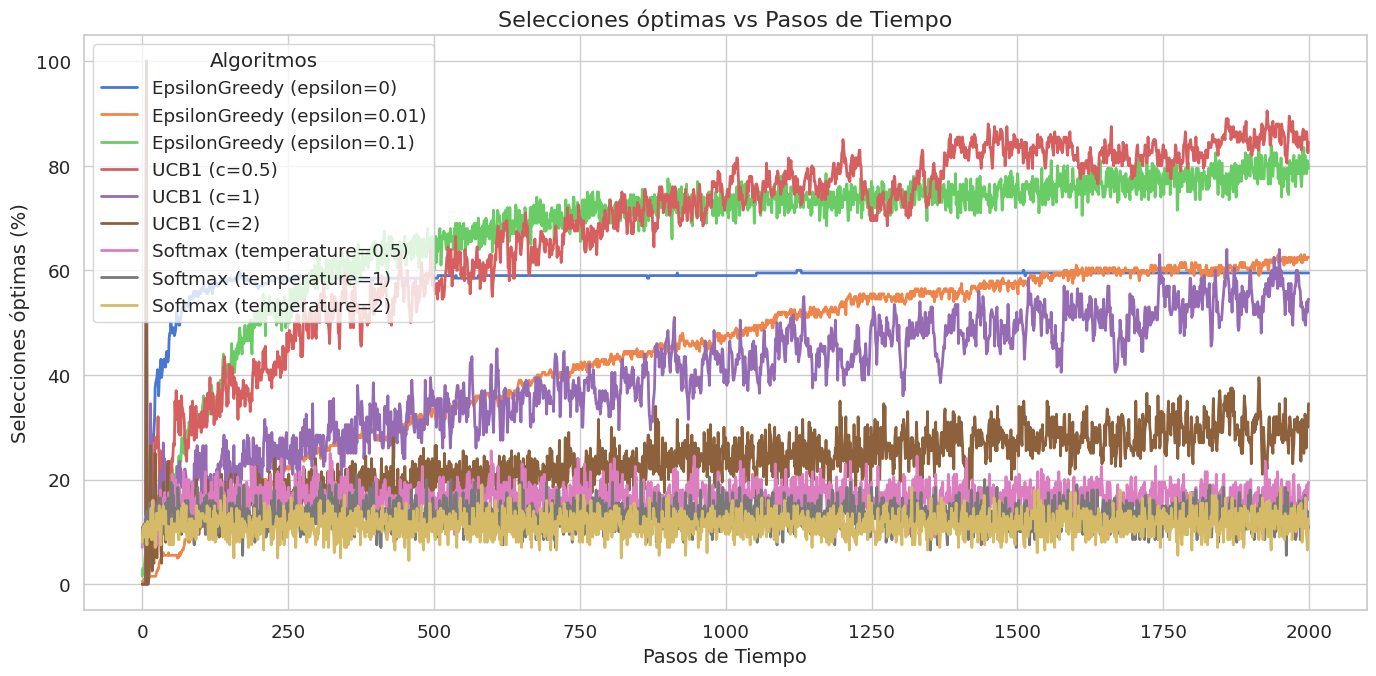

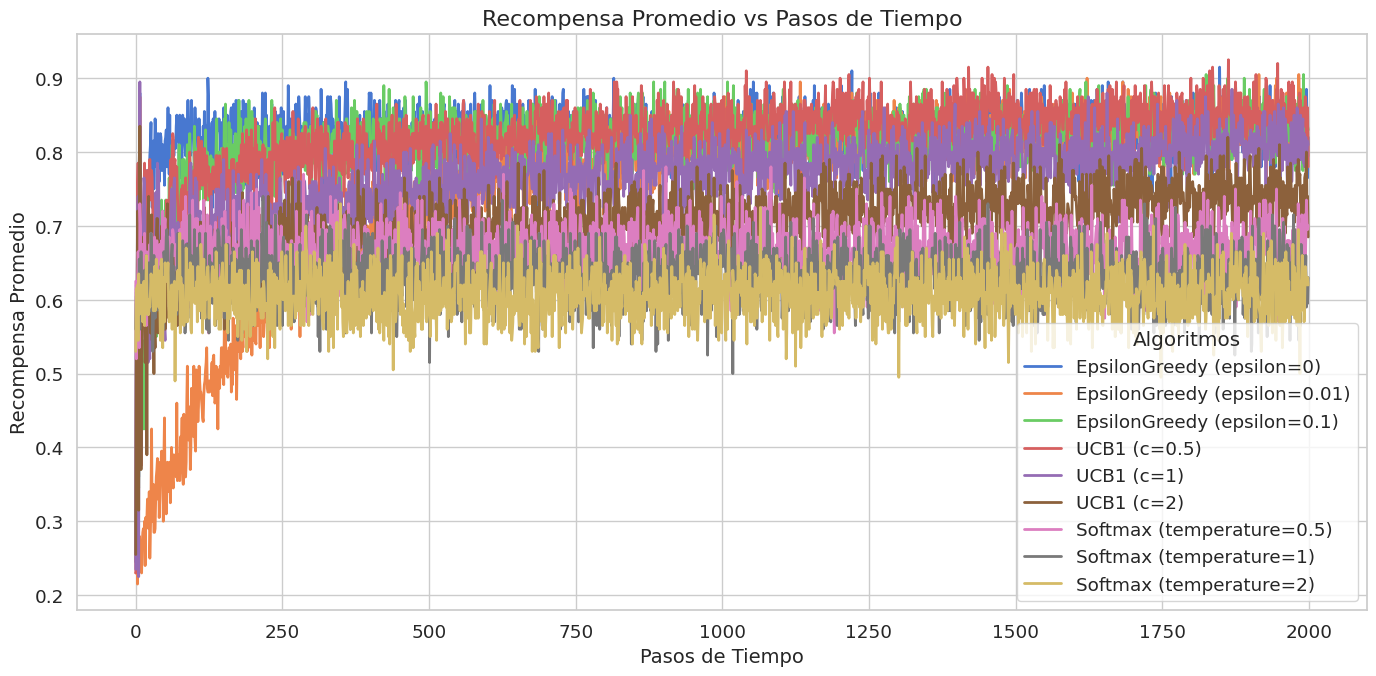

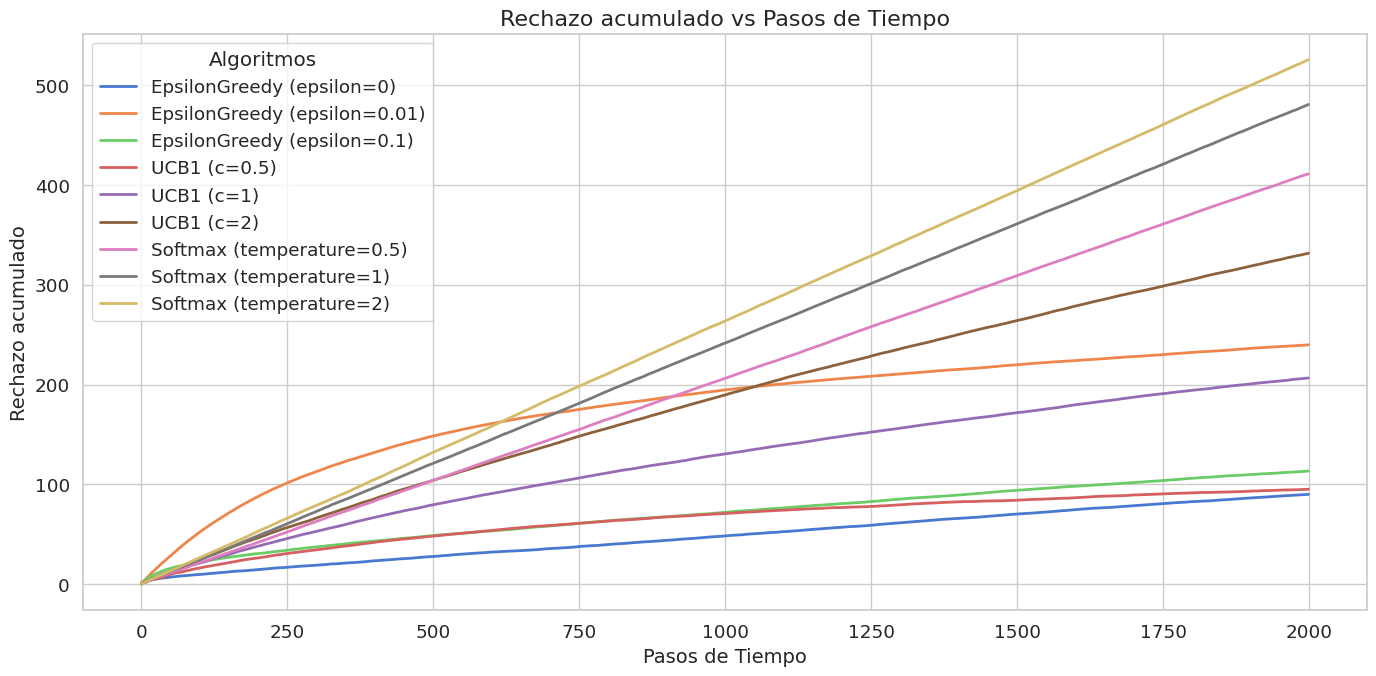

In [24]:
results_ex1_2 = execute_bandit_experiment(k=10, steps=2000, runs=runs, bandit=bandit)


### Valoración de los resultados

En este caso vemos unos resultados muy similares a los del apartado anterior, pero vemos como UCB-1 con c=0.5 consigue incluso situarse por encima de Epsilon-Greedy al haberle dado más tiempo para aprender el mejor brazo, acercándose a más del 80% de aciertos al final. Las variantes de UCB-1 con componentes exploratorias más marcadas vemos que tienen mayor dificultad para determinar cuál es el mejor brazo. De hecho, UCB-1 con c=1 se desempeña mejor que UCB-1 con c=2, lo cual confirma que, para este problema, una componente exploratoria con demasiado peso acaba siendo perjudicial.

También se puede apreciar como Epsilon-Greedy con epsilon=0.01, si bien tarda bastante más que la otra variante en aprender, poco a poco se va acercando a una solución bastante buena, al haberle dado un margen de tiempo mayor.

Vemos también como Softmax sigue aportando peores resultados que el resto de algoritmos.

En la gráfica de rechazo acumulado se sigue la línea de la ejecución para 1000 pasos, donde vemos que los algoritmos que mejor resultados nos dan tienen también un rechazo acumulado menor, en contraste con Softmax que parecen ser incapaces de encontrar el mejor brazo.


### Promedio de elecciones óptimas por algoritmo

Se presentan los promedios por algoritmo para esta primera variante del bandido. Vemos como los resultados coinciden con lo que se ha visto en las gráficas, teniendo a **UCB-1** con c=0.5 y **Epsilon-Greedy** con epsilon=0.1 los mejores resultados en cuanto a porcentaje de aciertos de todos los algoritmos.

Vemos también en los promedios como una componente exploratoria mayor penaliza el porcentaje de aciertos en **UCB-1** con mayor capacidad exploratoria.

In [25]:
avg_results_ex1 = get_results_average(results_ex1_1, results_ex1_2)
for algorithm_name, avg_rate in avg_results_ex1.items():
    print(f"Algoritmo {algorithm_name}: {avg_rate:.2f}% promedio de elecciones óptimas en el 20% último de steps")

Algoritmo EpsilonGreedy (epsilon=0): 60.00% promedio de elecciones óptimas en el 20% último de steps
Algoritmo EpsilonGreedy (epsilon=0.01): 52.78% promedio de elecciones óptimas en el 20% último de steps
Algoritmo EpsilonGreedy (epsilon=0.1): 75.10% promedio de elecciones óptimas en el 20% último de steps
Algoritmo UCB1 (c=0.5): 78.00% promedio de elecciones óptimas en el 20% último de steps
Algoritmo UCB1 (c=1): 47.30% promedio de elecciones óptimas en el 20% último de steps
Algoritmo UCB1 (c=2): 26.25% promedio de elecciones óptimas en el 20% último de steps
Algoritmo Softmax (temperature=0.5): 16.21% promedio de elecciones óptimas en el 20% último de steps
Algoritmo Softmax (temperature=1): 12.91% promedio de elecciones óptimas en el 20% último de steps
Algoritmo Softmax (temperature=2): 11.46% promedio de elecciones óptimas en el 20% último de steps


## Ejecución del experimento para Variante 2 del bandido

Nos disponemos a realizar el experimento para un bandido de 20 brazos, manteniendo la distribución binomial con valor máximo 10.

In [26]:
# Definimos el bandido (se comparte entre experimentos)
bandit = Bandit(arms=ArmBinomial.generate_arms(k=20, n=1)) # Generar un bandido con k brazos de distribución binomial. El valor de máxima recompensa será 10


### Ejecución de los algoritmos para 1000 steps

Vamos a llevar a cabo el experimento con la nueva variante del bandido para 1000 pasos.

Bandit with 20 arms: ArmBinomial(n=1, p=0.7), ArmBinomial(n=1, p=0.39), ArmBinomial(n=1, p=0.62), ArmBinomial(n=1, p=0.65), ArmBinomial(n=1, p=0.67), ArmBinomial(n=1, p=0.81), ArmBinomial(n=1, p=0.75), ArmBinomial(n=1, p=0.84), ArmBinomial(n=1, p=0.64), ArmBinomial(n=1, p=0.46), ArmBinomial(n=1, p=0.77), ArmBinomial(n=1, p=0.66), ArmBinomial(n=1, p=0.36), ArmBinomial(n=1, p=0.15), ArmBinomial(n=1, p=0.71), ArmBinomial(n=1, p=0.89), ArmBinomial(n=1, p=0.49), ArmBinomial(n=1, p=0.74), ArmBinomial(n=1, p=0.41), ArmBinomial(n=1, p=0.58)
Optimal arm for bandit is: 16 with expected reward=0.89

Algoritmo EpsilonGreedy (epsilon=0): 53.00% de elecciones óptimas en el 20% último de steps
Algoritmo EpsilonGreedy (epsilon=0): 54.60 de arrepentimiento acumulado

Algoritmo EpsilonGreedy (epsilon=0.01): 21.12% de elecciones óptimas en el 20% último de steps
Algoritmo EpsilonGreedy (epsilon=0.01): 143.80 de arrepentimiento acumulado

Algoritmo EpsilonGreedy (epsilon=0.1): 57.00% de elecciones óptimas

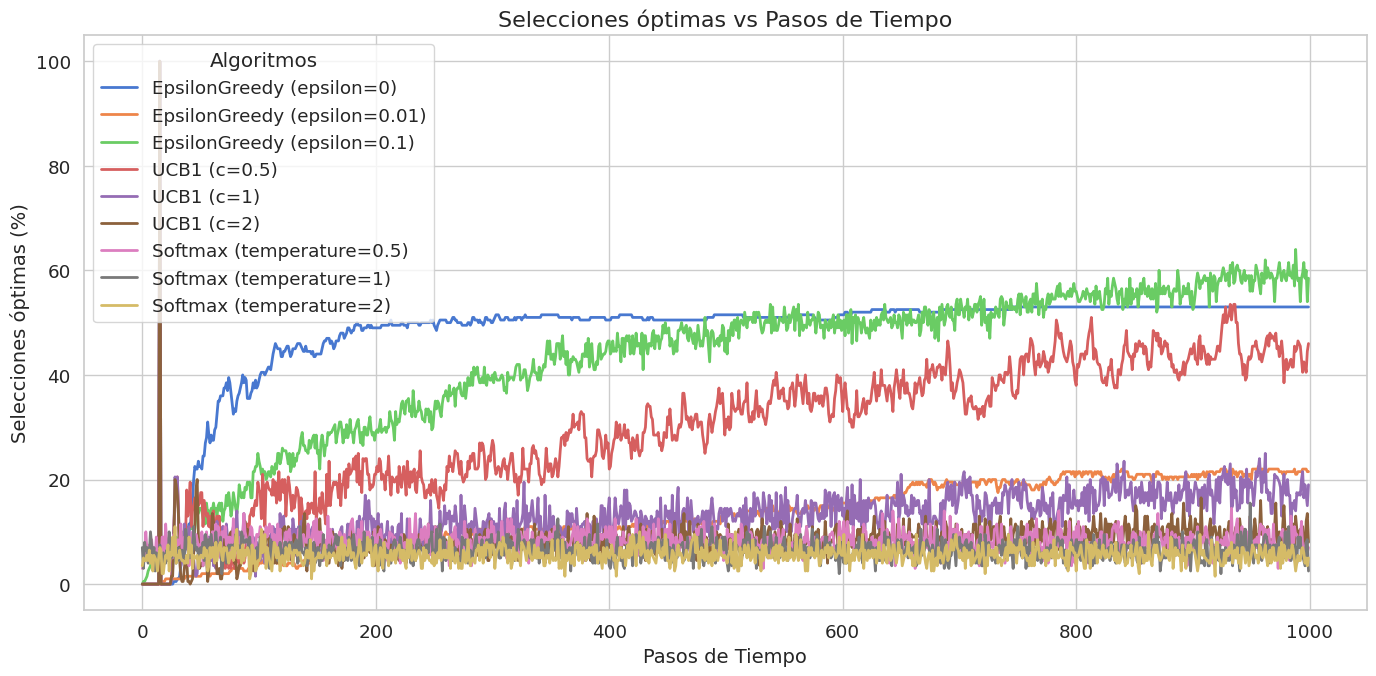

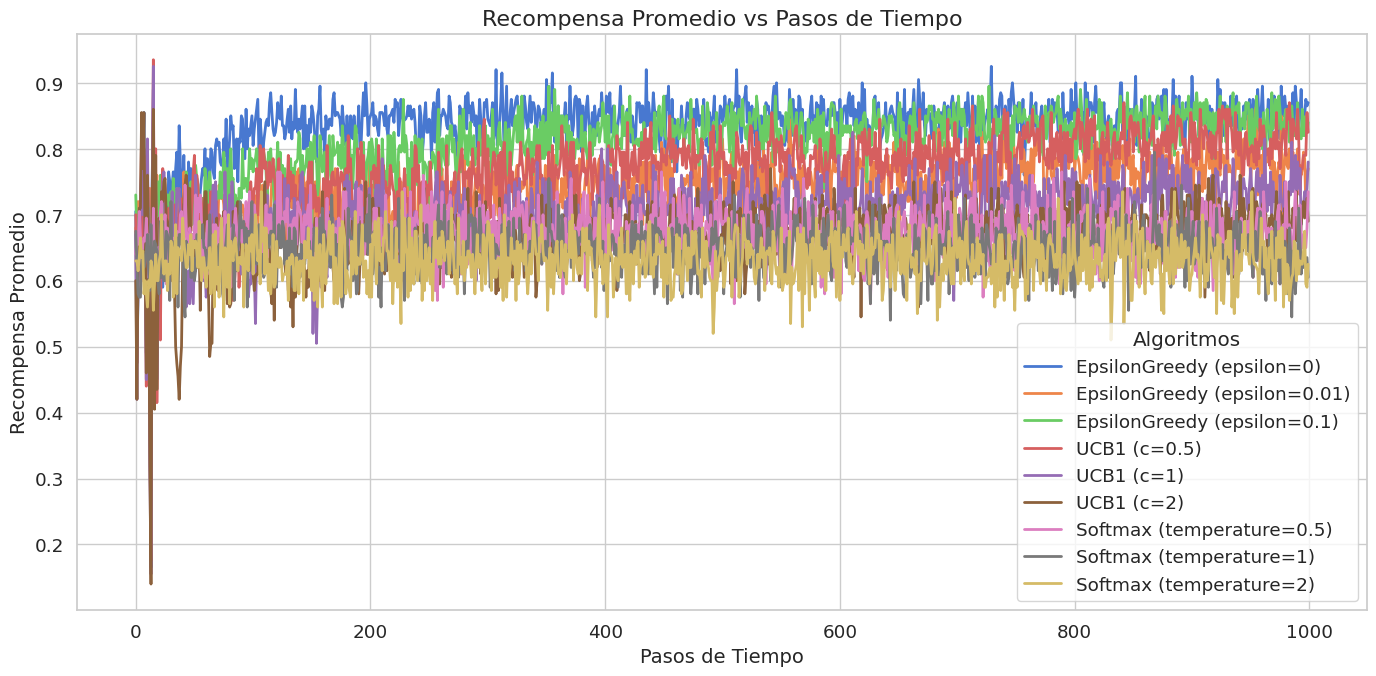

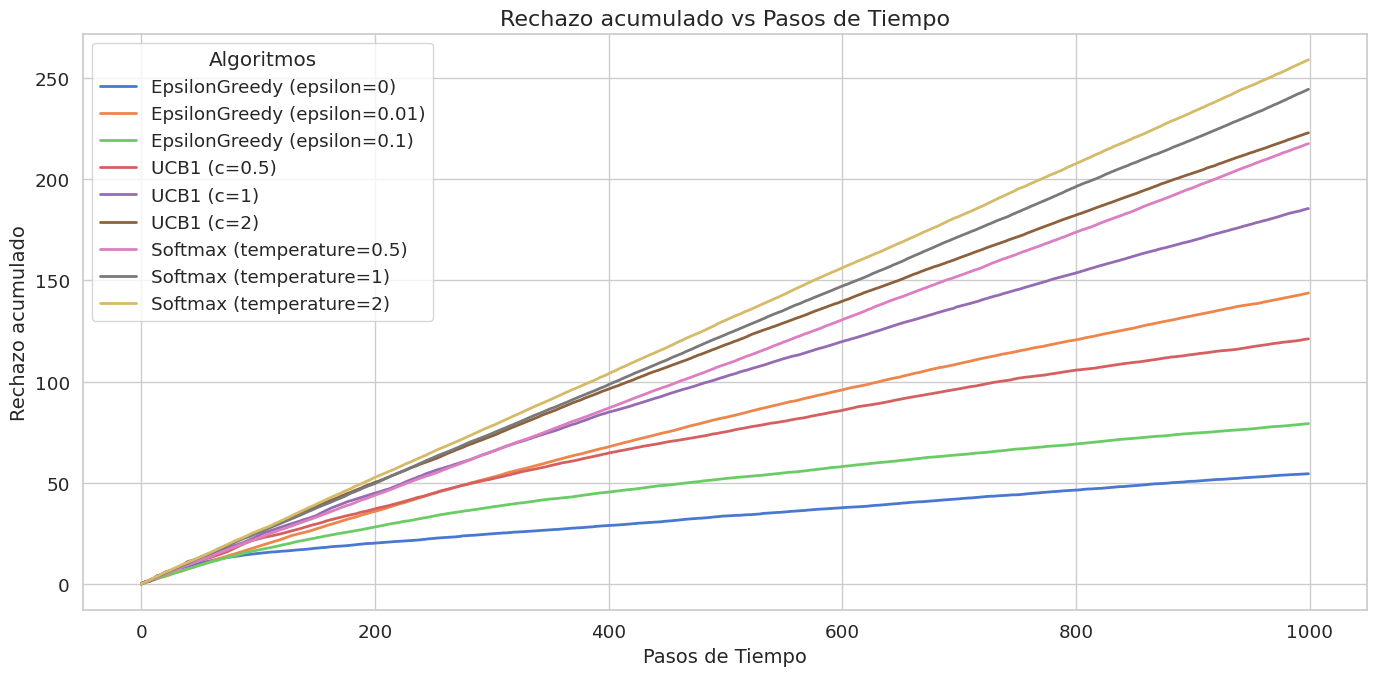

In [27]:
results_ex2_1 = execute_bandit_experiment(k=20, steps=1000, runs=runs, bandit=bandit)

### Valoración de los resultados

Vemos como, al aumentar el número de brazos, también aumenta la complejidad del problema y por tanto la dificultad que presenta para encontrar el brazo óptimo por parte del algoritmo. En la variante del bandido para 10 brazos, teníamos que los mejores algoritmos se acercaban al 80% de aciertos al final de la prueba, cuando en este caso apenas se acercan al 60% de aciertos en cuanto al brazo óptimo.

Vemos que, en este caso, el algoritmo que mejor ha funcionado es Epsilon-Greedy con epsilon=0.1, seguido de cerca por UCB-1 con c=0.5. Parece ser que el algoritmo Epsilon-Greedy con Epsilon=0, en la primera exploración inicial, también logró identificar un brazo bueno, pero se quedó estancado sin llegar a decantarse en ningún momento por el brazo óptimo.

Vemos como el resto de variantes de UCB-1, Softmax y Epsilon-Greedy, al haber aumentado la complejidad del problema, muestran un rendimiento por debajo de los anteriormente citados. En la gráfica de rechazo se puede ver como, a menor porcentaje de aciertos, mayor arrepentimiento acumulado, y viceversa.


### Ejecución de los algoritmos para 2000 steps

A continuación, vamos a repetir el experimento para 2000 pasos, manteniendo el número de runs.

Bandit with 20 arms: ArmBinomial(n=1, p=0.7), ArmBinomial(n=1, p=0.39), ArmBinomial(n=1, p=0.62), ArmBinomial(n=1, p=0.65), ArmBinomial(n=1, p=0.67), ArmBinomial(n=1, p=0.81), ArmBinomial(n=1, p=0.75), ArmBinomial(n=1, p=0.84), ArmBinomial(n=1, p=0.64), ArmBinomial(n=1, p=0.46), ArmBinomial(n=1, p=0.77), ArmBinomial(n=1, p=0.66), ArmBinomial(n=1, p=0.36), ArmBinomial(n=1, p=0.15), ArmBinomial(n=1, p=0.71), ArmBinomial(n=1, p=0.89), ArmBinomial(n=1, p=0.49), ArmBinomial(n=1, p=0.74), ArmBinomial(n=1, p=0.41), ArmBinomial(n=1, p=0.58)
Optimal arm for bandit is: 16 with expected reward=0.89

Algoritmo EpsilonGreedy (epsilon=0): 60.38% de elecciones óptimas en el 20% último de steps
Algoritmo EpsilonGreedy (epsilon=0): 75.93 de arrepentimiento acumulado

Algoritmo EpsilonGreedy (epsilon=0.01): 29.96% de elecciones óptimas en el 20% último de steps
Algoritmo EpsilonGreedy (epsilon=0.01): 236.90 de arrepentimiento acumulado

Algoritmo EpsilonGreedy (epsilon=0.1): 70.67% de elecciones óptimas

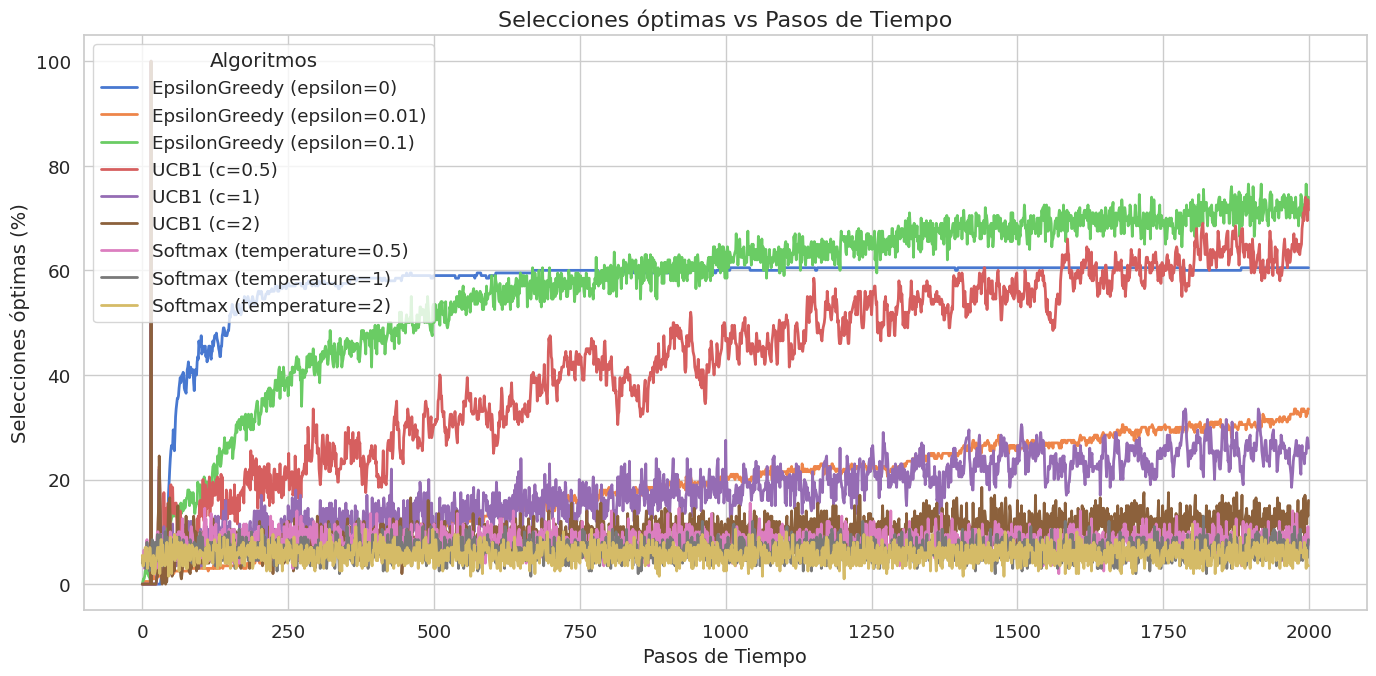

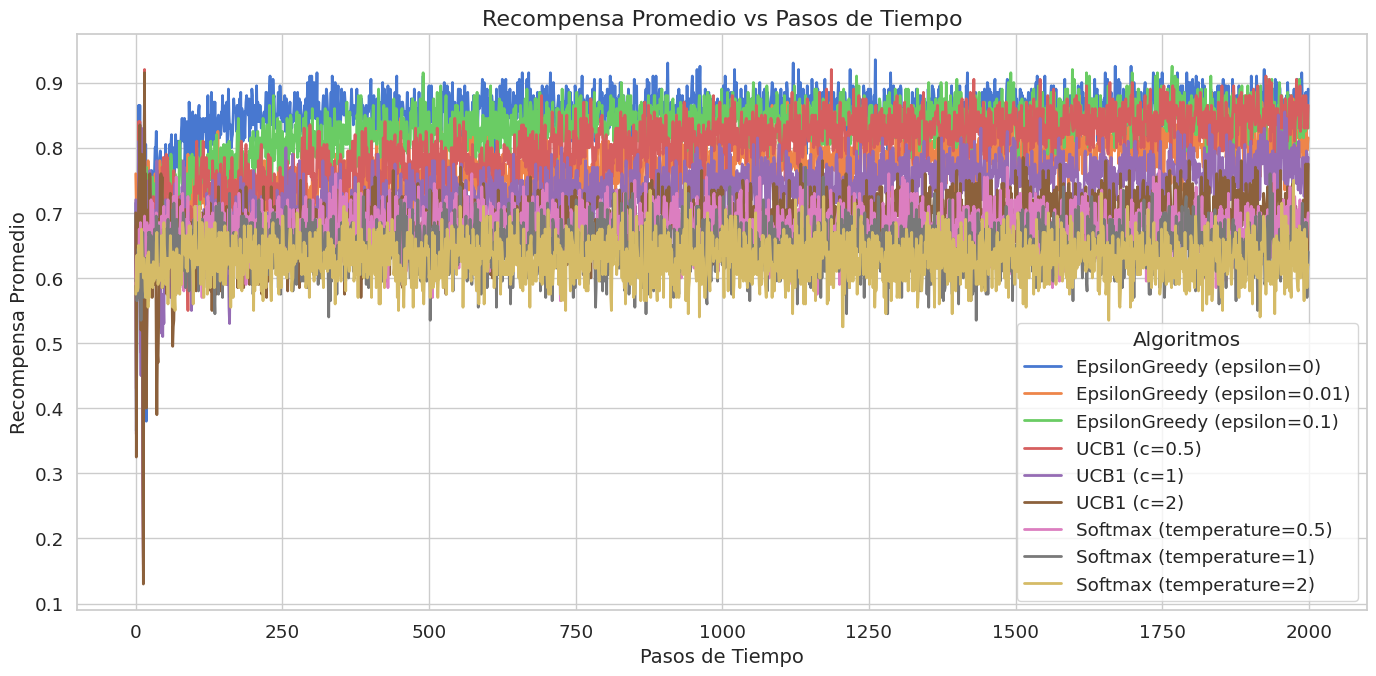

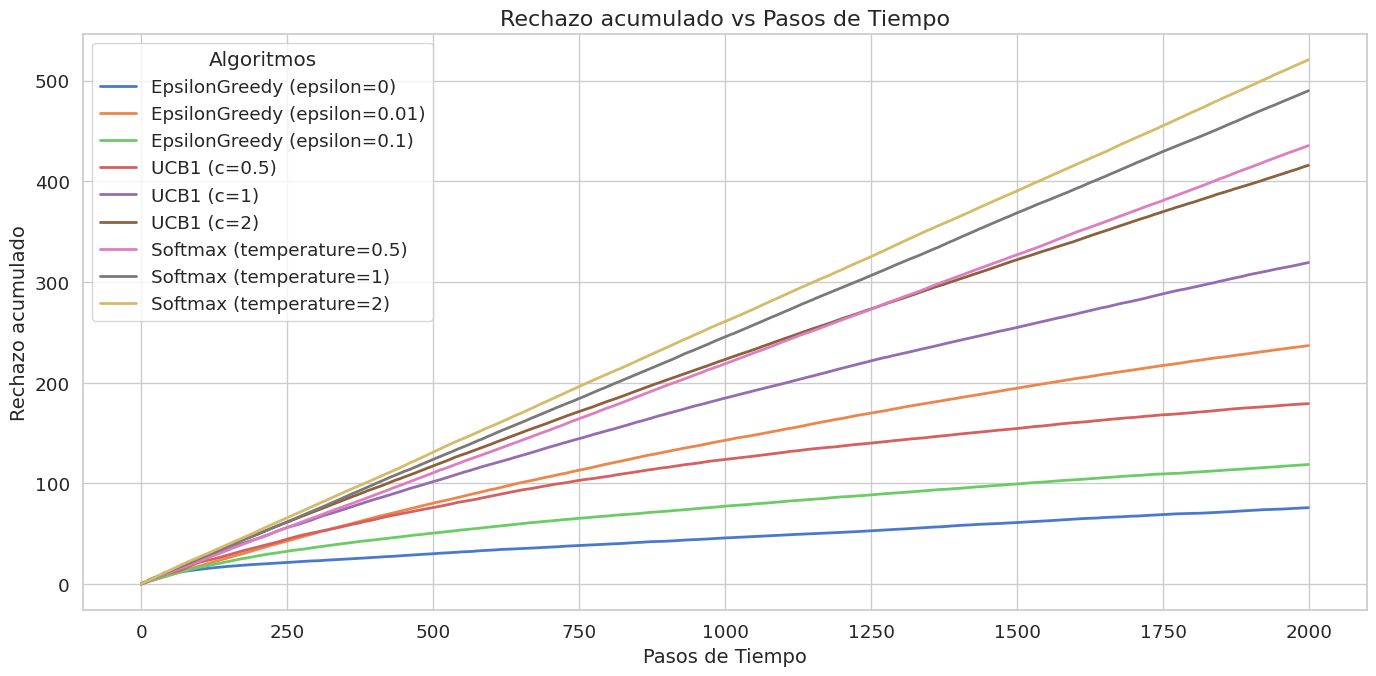

In [28]:
results_ex2_2 = execute_bandit_experiment(k=20, steps=2000, runs=runs, bandit=bandit)

### Valoración de los resultados

En esta prueba final hemos podido observar lo mismo que en la prueba anterior. Los algoritmos que mejor desempeño han tenido han sido UCB-1 con c= 0.5 y Epsilon-Greedy con epsilon=0.1. Al haberse ejecutado durante un número mayor de pasos, también han tenido más tiempo para "aprender" e incrementar su porcentaje de aciertos al final de un 60% con 1000 pasos a un 80% aproximadamente ahora que se testean en 2000 pasos.

Para el resto de algoritmos, cuanto más marcada es la componente exploratoria, por desempeñan, y esto se hace manente sobre todo en UCB-1.

### Promedio de elecciones óptimas por algoritmo

Se presentan los promedios por algoritmo para esta segunda variante del bandido para esta segunda prueba. Como ya se ha comentado, los algoritmos que mejor desempeño han presentado son UCB-1 con c=0.5, y Epsilon-Greedy con epsilon=0.1.

Vemos como la diferencia es significativa para las variantes de UCB-1. A mayor valor de c, peor porcentaje de aciertos promedio presentan en el 20% último de steps.

Vemos también como los valores para Softmax sugieren que es necesario encontrar valores más deseables para la temperatura si queremos que estén al nivel del resto.

In [29]:
avg_results_ex2 = get_results_average(results_ex2_1, results_ex2_2)
for algorithm_name, avg_rate in avg_results_ex2.items():
    print(f"Algoritmo {algorithm_name}: {avg_rate:.2f}% promedio de elecciones óptimas en el 20% último de steps")

Algoritmo EpsilonGreedy (epsilon=0): 56.69% promedio de elecciones óptimas en el 20% último de steps
Algoritmo EpsilonGreedy (epsilon=0.01): 25.54% promedio de elecciones óptimas en el 20% último de steps
Algoritmo EpsilonGreedy (epsilon=0.1): 63.84% promedio de elecciones óptimas en el 20% último de steps
Algoritmo UCB1 (c=0.5): 52.99% promedio de elecciones óptimas en el 20% último de steps
Algoritmo UCB1 (c=1): 21.30% promedio de elecciones óptimas en el 20% último de steps
Algoritmo UCB1 (c=2): 10.92% promedio de elecciones óptimas en el 20% último de steps
Algoritmo Softmax (temperature=0.5): 8.21% promedio de elecciones óptimas en el 20% último de steps
Algoritmo Softmax (temperature=1): 6.49% promedio de elecciones óptimas en el 20% último de steps
Algoritmo Softmax (temperature=2): 5.62% promedio de elecciones óptimas en el 20% último de steps


### Promedios totales de elecciones óptimas por algoritmo para todos los experimentos

Por último, presentamos los promedios totales para todas las pruebas. Estos resultados están en línea con las valoraciones que hemos realizado, donde destacan **Epsilon-Greedy** con epsilon=0.1 y **UCB-1** con c=0.5 por encima del resto. Podemos ver también como, en términos generales, estas variantes del bandido han supuesto una complejidad mayor para todas las variantes de todos los algoritmos, obteniendo estos unos promedios en cuanto a porcentaje de elecciones óptimas inferiores a los obtenidos para las distribuciones normal y binomial.


In [30]:
for algorithm_name, avg_rate in get_results_average(avg_results_ex1, avg_results_ex2).items():
    print(f"Algoritmo {algorithm_name}: {avg_rate:.2f}% promedio total de elecciones óptimas en el 20% último de steps")

Algoritmo EpsilonGreedy (epsilon=0): 58.34% promedio total de elecciones óptimas en el 20% último de steps
Algoritmo EpsilonGreedy (epsilon=0.01): 39.16% promedio total de elecciones óptimas en el 20% último de steps
Algoritmo EpsilonGreedy (epsilon=0.1): 69.47% promedio total de elecciones óptimas en el 20% último de steps
Algoritmo UCB1 (c=0.5): 65.50% promedio total de elecciones óptimas en el 20% último de steps
Algoritmo UCB1 (c=1): 34.30% promedio total de elecciones óptimas en el 20% último de steps
Algoritmo UCB1 (c=2): 18.58% promedio total de elecciones óptimas en el 20% último de steps
Algoritmo Softmax (temperature=0.5): 12.21% promedio total de elecciones óptimas en el 20% último de steps
Algoritmo Softmax (temperature=1): 9.70% promedio total de elecciones óptimas en el 20% último de steps
Algoritmo Softmax (temperature=2): 8.54% promedio total de elecciones óptimas en el 20% último de steps


## Conclusiones

Hemos realizado distintos experimentos para el bandido de k-brazos siguiendo una distribución de Bernoulli:

*  Experimento para bandido con K=10, steps=1000
*  Experimento para bandido con K=10, steps=2000
*  Experimento para bandido con K=20, steps=1000
*  Experimento para bandido con K=20, steps=2000

En todos los casos se han comparado distintas variantes del algoritmo Epsilon-Greedy, con epsilon=[0, 0.01, 0.1], el algoritmo UCB-1 con c=[0.5, 1, 2], y el algoritmo Softmax con $\tau$=[0.5, 1, 2]. Los parámetros han sido siempre los mismos para asegurar la consistencia de los resultados.

Siendo así, tenemos que, en todos los casos, los algoritmos que mejor comportamiento (Porcentaje de aciertos en último 20% de pasos vs rechazo acumulado) ha presentado han sido los algoritmos UCB-1 con c=0.5 y Epsilon-Greedy con epsilon=0.1.

Vemos que en este caso, valores exploratorios más altos perjudican a UCB-1 en contraposición con lo visto en otros tipos de distribución, donde c=1 por ejemplo lograba obtener resultados muy similares a los de c=0.5. No es el caso y vemos que, conforme aumenta c, disminuye el porcentaje de elecciones óptimas. Creemos que esto es debido a la naturaleza de esta distribución, donde no existe un abanico de valores, sino que únicamente devuelve 0 o 1 cada brazo, en cada caso.

Dado que nuestros algoritmos trabajan con recompensas acumuladas, este rango de valores o posibilidades tan estrecho puede introducir ruido (que varios brazos te den un "1" no da mucha información de cuál es el óptimo a priori, en contraposición de si uno te da "10" y otro "3", por ejemplo) y producir que cada algoritmo necesite muchos más pasos para averiguar cuál es el brazo óptimo.


